In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv('../data/bank.csv')
target = 'deposit'   # change if yours is different
y = df[target].map({'yes':1,'no':0})
X = df.drop(columns=[target])


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [8]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns


C:\Users\vaish\AppData\Local\Temp\ipykernel_5028\2790650992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [9]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])


Manual Controlled Experiment



n_estimators = [10, 50, 100, 200, 300]


In [10]:
n_list = [10, 50, 100, 200, 300]

train_scores = []
val_scores = []

for n in n_list:
    model = Pipeline([
        ('pre', preprocess),
        ('clf', RandomForestClassifier(n_estimators=n, random_state=42))
    ])
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_scores.append(f1_score(y_train, train_pred))
    val_scores.append(f1_score(y_val, val_pred))


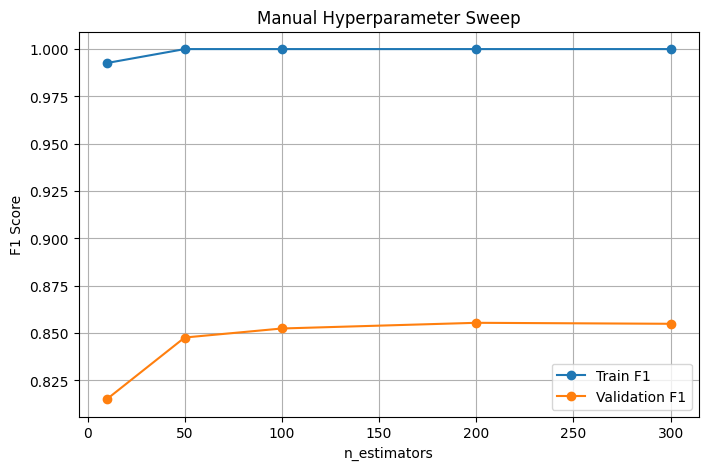

In [11]:
plt.figure(figsize=(8,5))
plt.plot(n_list, train_scores, marker='o', label='Train F1')
plt.plot(n_list, val_scores, marker='o', label='Validation F1')
plt.xlabel('n_estimators')
plt.ylabel('F1 Score')
plt.title('Manual Hyperparameter Sweep')
plt.legend()
plt.grid()
plt.savefig('../plots/perf_vs_hyperparam.png')
plt.show()


Observation:
- Very low n_estimators underfits
- Higher values improve validation score
- Beyond ~200, validation plateaus (no major gain)
- No strong overfitting observed with n_estimators in this dataset


Focused GridSearch


n_estimators = [150, 200, 250]
max_depth = [None, 10, 20]


In [12]:
grid_params = {
    'clf__n_estimators': [150, 200, 250],
    'clf__max_depth': [None, 10, 20]
}

model = Pipeline([
    ('pre', preprocess),
    ('clf', RandomForestClassifier(random_state=42))
])


In [13]:
grid = GridSearchCV(
    model,
    param_grid=grid_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [None, 10, ...], 'clf__n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [14]:
print("Best params:", grid.best_params_)
print("CV Mean F1:", grid.best_score_)
print("CV STD:", grid.cv_results_['std_test_score'][grid.best_index_])


Best params: {'clf__max_depth': 20, 'clf__n_estimators': 250}
CV Mean F1: 0.8493719847574871
CV STD: 0.0034127262280557098


In [15]:
best_model = grid.best_estimator_
final_pred = best_model.predict(X_val)
print("Validation F1:", f1_score(y_val, final_pred))
print("Validation Accuracy:", accuracy_score(y_val, final_pred))


Validation F1: 0.8548094373865699
Validation Accuracy: 0.8566950291088222


Manual sweep allowed observing bias/variance transition for Random Forest.
Extremely low n_estimators caused underfitting (low train & val score).
Increasing trees reduced variance and improved validation performance until ~200 trees,
after which gains diminished.
Based on this, the focused grid searched near 150–250.
Best parameters balanced performance and compute, avoiding exhaustive search.
